# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [3]:
base.head(10)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
5,60,1,151,67,2,2,0,0,0,0
6,61,1,157,93,3,1,0,0,1,0
7,62,2,178,95,3,3,0,0,1,1
8,48,1,158,71,1,1,0,0,1,0
9,54,1,164,68,1,1,0,0,0,0


In [4]:
base["weight"] = base["weight"].str.replace(",", ".").astype("float")

In [5]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [6]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
base.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
cholesterol,0
gluc,0
smoke,0
alco,0
active,0
cardio_disease,0


<Axes: >

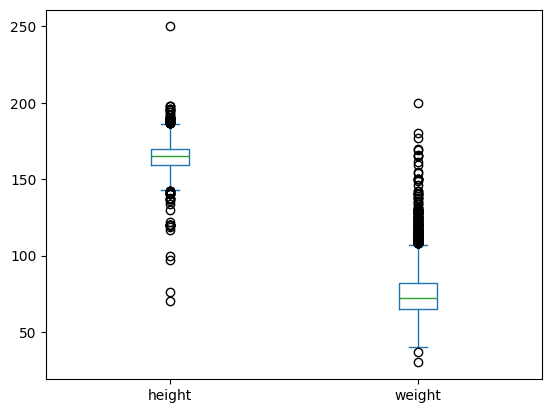

In [8]:
base[["height", "weight"]].plot.box()

In [9]:
base[base['height'].between(101,210)]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62.0,1,1,0,0,1,0
1,55,1,156,85.0,3,1,0,0,1,1
2,52,1,165,64.0,3,1,0,0,0,1
3,48,2,169,82.0,1,1,0,0,1,1
4,48,1,156,56.0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65.0,1,1,0,0,0,0
9996,50,1,160,93.0,2,1,0,0,1,1
9997,40,1,158,66.0,2,2,0,0,1,0
9998,50,1,168,70.0,3,1,0,0,1,1


In [10]:
df_base_clean = base[(base['height'] >= 140) & (base['height'] <= 210)].copy()

In [11]:
Q1 = df_base_clean['weight'].quantile(0.25)
Q3 = df_base_clean['weight'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5*IQR
limite_superior = Q3 + 1.5*IQR

In [12]:
df_base_clean = df_base_clean[(df_base_clean['weight'] >= limite_inferior) & (df_base_clean['weight'] <= limite_superior)]

<Axes: >

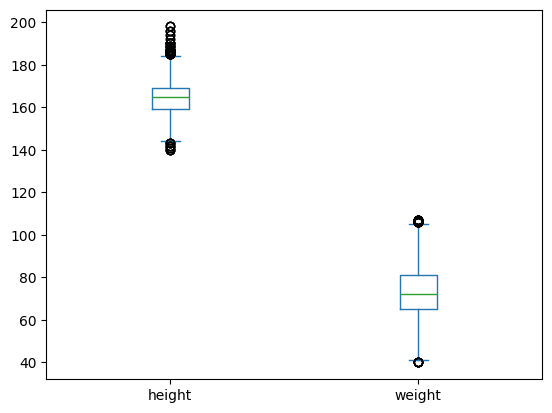

In [13]:
df_base_clean[["height", "weight"]].plot.box()

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


In [14]:
df_base_clean.columns
# df_base_clean.dtypes

Index(['age', 'gender', 'height', 'weight', 'cholesterol', 'gluc', 'smoke',
       'alco', 'active', 'cardio_disease'],
      dtype='object')

In [15]:
df_base_clean['age_group'] = pd.cut(df_base_clean['age'], bins=[29, 40, 50, 60, 70], labels=['30-40', '41-50', '51-60', '61-70'])
cardio_age = df_base_clean.groupby('age_group')['cardio_disease'].mean().reset_index()

/tmp/ipykernel_3993/174523775.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cardio_age = df_base_clean.groupby('age_group')['cardio_disease'].mean().reset_index()


/tmp/ipykernel_3993/4104737265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cardio_age, x='age_group', y='cardio_disease', palette='inferno')


Text(0, 0.5, 'Proporção de Casos (cardio_disease = 1)')

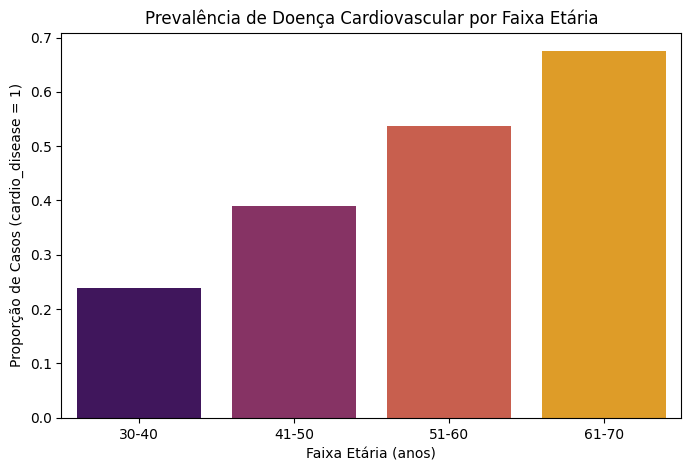

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(data=cardio_age, x='age_group', y='cardio_disease', palette='inferno')
plt.title("Prevalência de Doença Cardiovascular por Faixa Etária")
plt.xlabel("Faixa Etária (anos)")
plt.ylabel("Proporção de Casos (cardio_disease = 1)")

In [28]:
cardio_chol = df_base_clean.groupby('cholesterol')['cardio_disease'].mean().reset_index()

/tmp/ipykernel_3993/1711877494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cardio_chol, x='cholesterol', y='cardio_disease', palette='plasma')


([<matplotlib.axis.XTick at 0x7904f359a390>,
 [Text(0, 0, '1 - Normal'),
  Text(1, 0, '2 - Acima do Normal'),
  Text(2, 0, '3 - Muito Acima')])

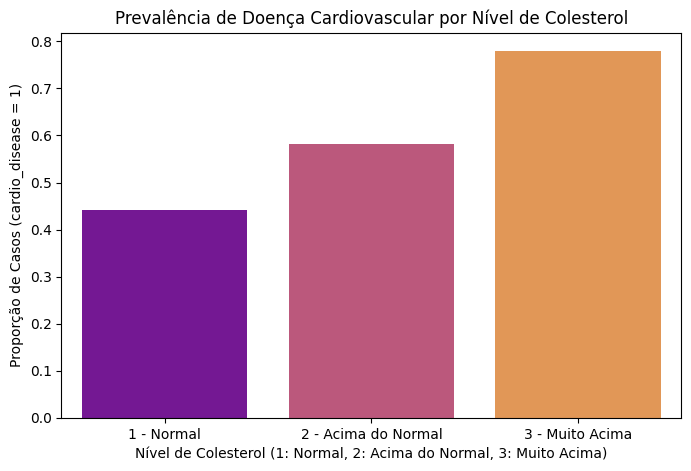

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(data=cardio_chol, x='cholesterol', y='cardio_disease', palette='plasma')
plt.title("Prevalência de Doença Cardiovascular por Nível de Colesterol")
plt.xlabel("Nível de Colesterol (1: Normal, 2: Acima do Normal, 3: Muito Acima)")
plt.ylabel("Proporção de Casos (cardio_disease = 1)")
plt.xticks([0,1,2], ['1 - Normal', '2 - Acima do Normal', '3 - Muito Acima'])

In [30]:
cardio_gluc = df_base_clean.groupby('gluc')['cardio_disease'].mean().reset_index()

/tmp/ipykernel_3993/1957949178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cardio_gluc, x='gluc', y='cardio_disease', palette='magma')


([<matplotlib.axis.XTick at 0x7904f32bfce0>,
 [Text(0, 0, '1 - Normal'),
  Text(1, 0, '2 - Acima do Normal'),
  Text(2, 0, '3 - Muito Acima')])

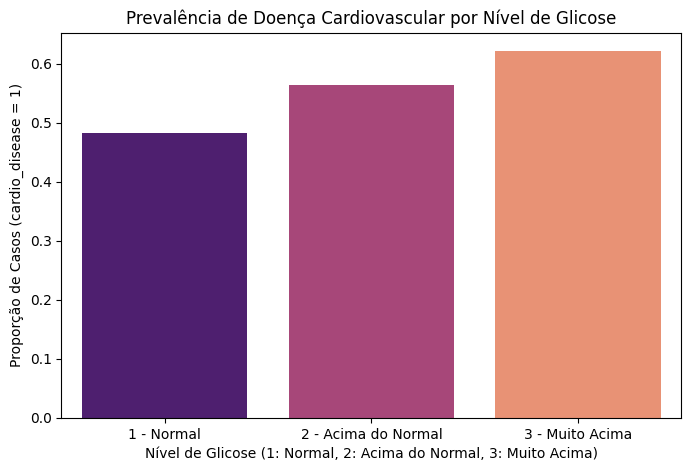

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(data=cardio_gluc, x='gluc', y='cardio_disease', palette='magma')
plt.title('Prevalência de Doença Cardiovascular por Nível de Glicose')
plt.xlabel('Nível de Glicose (1: Normal, 2: Acima do Normal, 3: Muito Acima)')
plt.ylabel('Proporção de Casos (cardio_disease = 1)')
plt.xticks([0, 1, 2], ['1 - Normal', '2 - Acima do Normal', '3 - Muito Acima'])

In [35]:
print("Age:", cardio_age)
print("Chol:", cardio_chol)
print("Gluc:", cardio_gluc)

Age:   age_group  cardio_disease
0     30-40        0.238397
1     41-50        0.389485
2     51-60        0.536610
3     61-70        0.675088
Chol:    cholesterol  cardio_disease
0            1        0.442274
1            2        0.580838
2            3        0.779425
Gluc:    gluc  cardio_disease
0     1        0.482613
1     2        0.564067
2     3        0.621277


A partir da análise dos gráficos acima, observa-se que a incidência das doenças cardiácas aumentam significativamente com a idade e com as condições de saúde em níveis muito acima, para colesterol e glicose.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



In [39]:
matriz_correlacao = base.corr()
print("Matriz de Correlação")
print(matriz_correlacao.round(2))

Matriz de Correlação
                 age  gender  height  weight  cholesterol  gluc  smoke  alco  \
age             1.00   -0.02   -0.08    0.05         0.17  0.09  -0.05 -0.04   
gender         -0.02    1.00    0.49    0.15        -0.03 -0.03   0.33  0.18   
height         -0.08    0.49    1.00    0.29        -0.04 -0.02   0.19  0.11   
weight          0.05    0.15    0.29    1.00         0.13  0.10   0.07  0.08   
cholesterol     0.17   -0.03   -0.04    0.13         1.00  0.43   0.02  0.02   
gluc            0.09   -0.03   -0.02    0.10         0.43  1.00   0.02  0.01   
smoke          -0.05    0.33    0.19    0.07         0.02  0.02   1.00  0.33   
alco           -0.04    0.18    0.11    0.08         0.02  0.01   0.33  1.00   
active         -0.02    0.01   -0.01   -0.02         0.02  0.00   0.03  0.04   
cardio_disease  0.24    0.00   -0.01    0.18         0.22  0.08  -0.02 -0.01   

                active  cardio_disease  
age              -0.02            0.24  
gender          

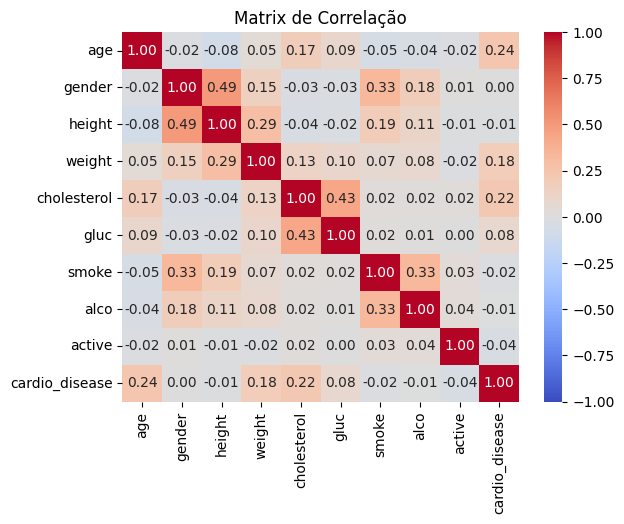

In [41]:
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrix de Correlação")
plt.show()

Algumas correlações expressivas são: Idade (mais idade), gênero do fumante, colesterol, ser fumante e consumir bebidas alcólicas e o mais expressivo de todos: glicose em níveis muito acima do normal.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [47]:
X = df_base_clean.drop(columns=['cardio_disease', 'age_group'])
y = df_base_clean['cardio_disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
print("Dimensões\n")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")
print("\nProporção da classe em y_train\n")
print(y_train.value_counts(normalize=True))
print("\nProporção da classe em y_test\n")
print(y_test.value_counts(normalize=True))

Dimensões

X_train: (7787, 9) | y_train: (7787,)
X_test: (1947, 9) | y_test: (1947,)

Proporção da classe em y_train

cardio_disease
0    0.501348
1    0.498652
Name: proportion, dtype: float64

Proporção da classe em y_test

cardio_disease
0    0.501284
1    0.498716
Name: proportion, dtype: float64


A distribuição da variável alvo mantida idêntica em ambos os conjuntos confirma o funcionamento correto do parâmetro stratify=y na função train_test_split. Assim a base está pronta para o treinamento do modelo.

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [62]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [63]:
print("Intercept:", model.intercept_[0])
coef_df = pd.DataFrame({
    'Atributo': X.columns,
    'Coeficiente': model.coef_[0]
}).sort_values(by= 'Coeficiente', ascending=False)
print(coef_df)

Intercept: 0.007056701414658363
      Atributo  Coeficiente
0          age     0.420145
4  cholesterol     0.405603
3       weight     0.377320
1       gender     0.033538
7         alco    -0.029794
6        smoke    -0.038977
5         gluc    -0.061486
8       active    -0.068472
2       height    -0.118492


In [65]:
y_pred_train = model.predict(X_train_scaled)
y_proba_train = model.predict_proba(X_train_scaled)[:, 1]

print(f"Acurácia: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precisão: {precision_score(y_train, y_pred_train):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_pred_train):.4f}")
print("\nMatriz de Confusão:\n", confusion_matrix(y_train, y_pred_train))

Acurácia: 0.6346
Precisão: 0.6432
Recall: 0.6003
F1-Score: 0.6210
ROC AUC: 0.6346

Matriz de Confusão:
 [[2611 1293]
 [1552 2331]]


O modelo não está fazendo boas previsões. A acurácia 63,4% sob a curva ROC(AUC) de 63,4% também, indica que estão com um desempenho similar ao de um chute aleatório (50%).
Alta taxa de faixa falsos negativos (Recall de 60,0%).

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [64]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.4f}")
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))


Acurácia: 0.6477
Precisão: 0.6531
Recall: 0.6262
F1-Score: 0.6393
ROC AUC: 0.6476

Matriz de Confusão:
 [[653 323]
 [363 608]]


O resultado confirma baixa capacidade preditiva geral (64,77% de acerto). O modelo falhou em identificar 363 indivíduos doentes do total de 971 positivos presentes na base mais de 37% de erro nos falsos negativos. E a curva ROC AUC indica proximidade com a classificação aleatória de 50%.

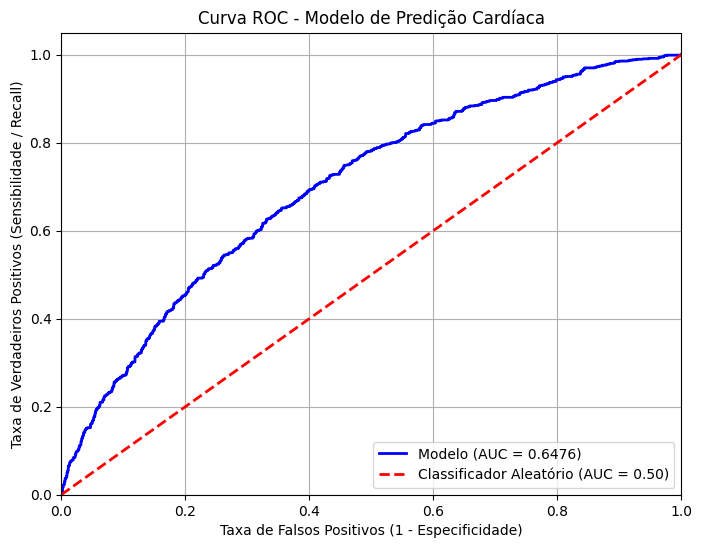

In [66]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Modelo (AUC = {roc_auc_score(y_test, y_pred):.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Classificador Aleatório (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)')
plt.title('Curva ROC - Modelo de Predição Cardíaca')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

A linha azul (modelo) está acima da linha pontilhada vermelha (chute aleatório, AUC = 0.50). Isso confirma que o modelo aprendeu um padrão com sinal estatístico superior ao acaso. O valor de AUC igual a 64,7% indica um modelo fraco para diagnósticos médicos. Um modelo com boa capacidade discriminativa apresenta AUC acima de 80%, aproximando a curva do canto superior esquerdo (onde a Taxa de Verdadeiros Positivos é 1 e a de Falsos Positivos é 0).

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A regressão logística é um modelo de aprendizagem de máquina supervisionado, que é usado para prever a probabilidade de um evento ocorrer; como verdadeiro ou falso, sim ou não. Por isso é classificada como um modelo classificatório, pois classifica de uma maneira discreta as informações. O cálculo interno gera uma probabilidade contínua, mas a decisão final é a atribuição a uma classe predefinida. O que se tem de comum entre a regressão logistica e linear é que ambos calculam uma combinação linear das variáveis de entrada multiplicada por coeficientes.